# **Access interpretability through Preprocessing - MIT-BIH-Database**

### **Objective:** In this notebook we will present an approach to make the results of a deep learning model interpretable in such a way that the classification decision becomes comprehensible for a physician. From a business perspective, such an algorithm is expected to have a significantly higher acceptance in terms of clinical implementation. We face a particular challenge here with regard to our database. We will discuss the problem and present 2 different approaches to solve it. In this context, we will also present an alternative deep learning model.  

## **1. The Model:** 

#### **Basic Data Prepataion:** 

In [6]:
# Loading Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical

# Loading Data
mitbih_test_df = pd.read_csv("mitbih_test.csv")
mitbih_train_df = pd.read_csv("mitbih_train.csv")

# Renaming the columns
new_column_names = range(1, len(mitbih_train_df.columns) + 1)
mitbih_train_df.columns = new_column_names
new_column_names = range(1, len(mitbih_test_df.columns) + 1)
mitbih_test_df.columns = new_column_names

# Transforming the Target Variable to Integer
mitbih_train_df[188]=mitbih_train_df[188].astype(int)
mitbih_test_df[188]=mitbih_test_df[188].astype(int)

# Shuffle Rows
mitbih_train_df = mitbih_train_df.sample(frac=1, random_state=42).reset_index(drop=True)
mitbih_test_df = mitbih_test_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Train Test Split (Original Data without further Preprocessing)
X_train_orig = mitbih_train_df.iloc[:, :-1]
y_train_orig = mitbih_train_df.iloc[:, -1]
X_test_orig = mitbih_test_df.iloc[:, :-1]
y_test_orig = mitbih_test_df.iloc[:, -1]

print("Number of Examples per Class Y_train_orig: ", dict(pd.Series(y_train_orig).value_counts()))
print("Number of Examples per Class Y_test_orig: ", dict(pd.Series(y_test_orig).value_counts()))

# One-hot encoding of target variables for multi-class classification
y_train_orig = to_categorical(y_train_orig, num_classes=5)
y_test_orig = to_categorical(y_test_orig, num_classes=5)

# Conversion of DataFrames into NumPy arrays and addition of a feature dimension
X_train_orig = np.expand_dims(X_train_orig.values, axis=-1)
X_test_orig = np.expand_dims(X_test_orig.values, axis=-1)

# Verification of correct Format
print("Shape of X_train_orig, y_train_orig: ", X_train_orig.shape, y_train_orig.shape) 
print("Shape of X_test_orig, y_test_orig: ", X_test_orig.shape, y_test_orig.shape) 

Number of Examples per Class Y_train_orig:  {0: 72470, 4: 6431, 2: 5788, 1: 2223, 3: 641}
Number of Examples per Class Y_test_orig:  {0: 18117, 4: 1608, 2: 1448, 1: 556, 3: 162}
Shape of X_train_orig, y_train_orig:  (87553, 187, 1) (87553, 5)
Shape of X_test_orig, y_test_orig:  (21891, 187, 1) (21891, 5)


#### **Model Architecture:** 
**This model is a 1D Convolutional Neural Network (1D-CNN) architecture designed for multi-class classification with residual 
connections to improve feature learning especially for sequential Data.** 

**Key Components of the Model:**

1. Input Layer:
- The input shape is (187, 1), representing a time-series signal with 187 timesteps and a single feature. This korresponds to the EKG-Data.

2. Convolutional and Pooling Layers:
- The first layer is a Conv1D layer with 64 filters, kernel size of 3, and ReLU activation.
- A MaxPooling1D layer with a pool size of 2 is applied to downsample the input

3. Residual Blocks:
- The model includes three residual blocks, each consisting of:
    - Two Conv1D layers with the same filter size and kernel size of 3.
    - BatchNormalization layers after each convolution to stabilize and speed up training.
    - ReLU activation for non-linearity.
    - A shortcut connection adds the input to the block's output to form a residual connection.
    - Filter sizes for the residual blocks:
        - Block 1: 64 filters
        - Block 2: 128 filters
        - Block 3: 256 filters

4. Flatten Layer:
- The output of the last residual block is flattened into a single vector with 23,808 elements to connect it to fully connected layers.

5. Fully Connected Dense Layers:
- The dense layers progressively reduce the feature dimensions:
    - First dense layer: 128 neurons with ReLU activation and a dropout of 40% to prevent overfitting.
    - Second dense layer: 64 neurons with ReLU activation and a dropout of 30% to prevent overfitting.

6. Output Layer:
- A dense layer with 5 neurons and a softmax activation function for multi-class classification. The model outputs probabilities for each of the 5 classes.

**Total Parameters:**
- The model has 3,449,469 trainable parameters, primarily concentrated in the dense layers and residual blocks.

**Optimizer and Loss Function:**
- The model uses the Adam optimizer with a learning rate of 0.0001 for adaptive gradient descent.
- The loss function is categorical_crossentropy, suitable for multi-class classification tasks.


In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dense, Dropout, Flatten, BatchNormalization, Activation, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Residual Block Definition
def residual_block(x, filters, kernel_size=3):
    # Shortcut connection
    shortcut = x

    # Adjust shortcut dimensions if necessary
    if x.shape[-1] != filters:
        shortcut = Conv1D(filters=filters, kernel_size=1, padding='same')(shortcut)
    
    # First Conv1D layer
    x = Conv1D(filters=filters, kernel_size=kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Second Conv1D layer
    x = Conv1D(filters=filters, kernel_size=kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    # Add the shortcut to the output
    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

# Model input
inputs = Input(shape=(187, 1), name="Input")  # Shape adjusted according to preprocessing

# 1D-CNN layer with the best hyperparameters
x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
x = MaxPooling1D(pool_size=2)(x)
x = BatchNormalization()(x)

# Residual block 1
x = residual_block(x, filters=64)

# Residual block 2
x = residual_block(x, filters=128)

# Residual block 3
x = residual_block(x, filters=256)

# Flatten layer
x = Flatten()(x)

# Dense layers with the best dropout values
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)  # Best dropout for layer 1

x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)  # Best dropout for layer 2

# Output layer for multi-class classification
output_layer = Dense(5, activation='softmax')(x)

# Create the model
model = Model(inputs=inputs, outputs=output_layer)

# Compile the model with the best learning rate
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

print("Model Summary:")
model.summary()

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Train the model
training_history = model.fit(
    X_train_orig,
    y_train_orig,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)

# Evaluate the model
evaluation = model.evaluate(X_test_orig, y_test_orig)
print(f"Test loss: {evaluation[0]}, Test accuracy: {evaluation[1]}")

Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 187, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 187, 64)   │        256 │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 93, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 93, 64)    │        256 │ max_pooling1d[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 93, 64)    │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 93, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 93, 64)    │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 93, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 93, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 93, 128)   │     24,704 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 128)   │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 93, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 93, 128)   │     49,280 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 128)   │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 93, 128)   │      8,320 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 93, 128)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 93, 128)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                 

 Total params: 3,495,685 (13.33 MB)

 Trainable params: 3,493,765 (13.33 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/50
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 79s 35ms/step - accuracy: 0.9154 - loss: 0.3161 - val_accuracy: 0.9736 - val_loss: 0.1004
Epoch 2/50
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 80s 37ms/step - accuracy: 0.9670 - loss: 0.1261 - val_accuracy: 0.9779 - val_loss: 0.0778
Epoch 3/50
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 92s 42ms/step - accuracy: 0.9756 - loss: 0.0900 - val_accuracy: 0.9817 - val_loss: 0.0692
Epoch 4/50
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 84s 39ms/step - accuracy: 0.9791 - loss: 0.0745 - val_accuracy: 0.9816 - val_loss: 0.0692
Epoch 5/50
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 92s 42ms/step - accuracy: 0.9833 - loss: 0.0605 - val_accuracy: 0.9814 - val_loss: 0.0653
Epoch 6/50
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 93s 43ms/step - accuracy: 0.9849 - loss: 0.0511 - val_accuracy: 0.9863 - val_loss: 0.0507
Epoch 7/50
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 87s 40ms/step - accuracy: 0.9867 - loss: 0.0441 - val_accuracy: 0.9861 - val_loss: 0.0522
Epoch 8/50
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 99s 45ms/step - accuracy: 0.9882 -

#### **Results on original Data:**

685/685 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step
Classification report: 
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     18117
           1       0.91      0.81      0.86       556
           2       0.96      0.97      0.96      1448
           3       0.91      0.77      0.83       162
           4       0.99      0.99      0.99      1608

    accuracy                           0.99     21891
   macro avg       0.96      0.90      0.93     21891
weighted avg       0.99      0.99      0.99     21891



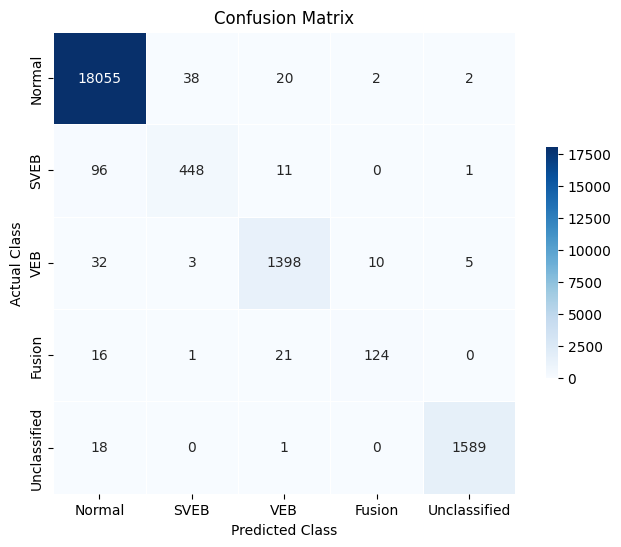

In [8]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

y_pred_orig = model.predict(X_test_orig)
y_pred_classes_orig = np.argmax(y_pred_orig, axis=1)
y_true_classes_orig = np.argmax(y_test_orig, axis=1)
report = classification_report(y_true_classes_orig, y_pred_classes_orig)
print("Classification report: \n", report)


cm = confusion_matrix(y_true_classes_orig, y_pred_classes_orig)
class_names = ['Normal', 'SVEB', 'VEB', 'Fusion', 'Unclassified']
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

## **2. The Problem:**